# makemore Part 2 — MLP with learned character embeddings (Bengio 2003)

**Video:** https://www.youtube.com/watch?v=TCH_1BHY58I  
**Reference notebook:** `../nn-zero-to-hero/lectures/makemore/makemore_part2_mlp.ipynb`  
**Paper:** [Bengio et al. 2003 — A Neural Probabilistic Language Model](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)

## What this notebook builds

A character-level MLP language model that overcomes the two big limits of the bigram in Part 1:
1. **Fixed context length > 1.** Look at `block_size=3` previous characters instead of just 1. Any n-gram model could do this, but count tables blow up combinatorially.
2. **Learned character embeddings, not one-hots.** Each character becomes a small dense vector (e.g. 2 or 10 dims) that gradient descent tunes. This lets the model *generalize* — if `xyz` never appeared but similar-context tokens did, the embedding-space geometry can still produce reasonable predictions.

That combination — fixed-window context + learned embeddings — is the Bengio 2003 architecture, and it's the direct precursor of every transformer you use today.

**Sections 11-13 add a bonus:** systematic hyperparameter search (random + Bayesian) using Optuna, with deterministic seeding for reproducibility. **Result:** test loss **~2.20**, competitive with Karpathy's canonical ~2.17 (within noise), starting from a small model that alone only reaches ~2.37.

## New concepts vs Part 1

- `block_size` (context window)
- Embedding table `C` and `C[X]` lookup
- MLP with hidden layer + tanh activation
- `F.cross_entropy` (numerically stable NLL via log-sum-exp trick)
- Mini-batch SGD
- Learning rate finder
- Train/dev/test split (80/10/10)
- **Random search & Bayesian hyperparameter optimization** (Sections 11-13, beyond the video)
- **Deterministic RNG seeding** for reproducible hyperparameter search results

## Rules

1. **TYPE. Do not paste.**
2. **Pause and predict** before running any new operation.
3. **Break things on purpose** — change a hyperparameter after each section works.
4. **Log what surprised you** in the session log below.

**Every time you open this notebook:** `Kernel → Restart Kernel and Run All Cells`.

## Section 1 — Load the dataset

Same `names.txt` as Part 1. Same `stoi`/`itos` with `.` at index 0.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

names = open('names.txt').read().splitlines()
chars = ['.'] + sorted(set(''.join(names)))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
print(len(names), len(chars))    # 32033 names, 27 chars

32033 27


## Section 2 — Build the dataset with context window

Instead of `(prev_char, next_char)` bigram pairs, build `(prev_3_chars, next_char)` triples (or however wide `block_size` is). For `emma` with `block_size=3`:

```
context             target
'...'    (0,0,0)  →  'e'   (5)
'..e'    (0,0,5)  →  'm'   (13)
'.em'    (0,5,13) →  'm'   (13)
'emm'    (5,13,13) → 'a'   (1)
'mma'    (13,13,1) → '.'   (0)
```

**Sliding window mechanic:** `context = context[1:] + [ix]` — drop the leftmost, append the new. This idiom shows up constantly in sequence modeling.

In [2]:
block_size = 3   # context length

X, Y = [], []
for w in names:
    context = [0] * block_size            # start with all '.'s
    for ch in w + '.':                    # walk the name + end token
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]      # slide the window
X = torch.tensor(X)
Y = torch.tensor(Y)
print(X.shape, X.dtype, Y.shape, Y.dtype)  # (228146, 3) int64, (228146,) int64

torch.Size([228146, 3]) torch.int64 torch.Size([228146]) torch.int64


## Section 3 — Train/dev/test split (80/10/10)

**Why split?** Training loss lies — a model with enough parameters memorizes the training set (overfitting) and gives terrible generalization. The dev set tells you the truth. The test set is held sacred; touch it only at the very end for a final unbiased number.

**The three roles:**
- **train** — fit the weights
- **dev** — pick hyperparameters (embed dim, hidden size, lr, iterations)
- **test** — one final evaluation number, never optimized against

In [3]:
import random
random.seed(42)
random.shuffle(names)
n1 = int(0.8 * len(names))
n2 = int(0.9 * len(names))

def build_dataset(words, block_size=3):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

Xtr,  Ytr  = build_dataset(names[:n1])     # training
Xdev, Ydev = build_dataset(names[n1:n2])   # dev / validation
Xte,  Yte  = build_dataset(names[n2:])     # test (touch only at end)
print(Xtr.shape, Xdev.shape, Xte.shape)    # (~182k, 3), (~23k, 3), (~23k, 3)

torch.Size([182625, 3]) torch.Size([22655, 3]) torch.Size([22866, 3])


## Section 4 — Embedding table

**The pivotal idea of this video.** Each of the 27 characters gets a learned dense vector (initially random, updated by gradient descent). The embedding table `C` has shape `(vocab_size, embedding_dim)`.

**The lookup `C[X]`** — advanced indexing with an integer tensor. If `X` has shape `(N, block_size)` and `C` has shape `(27, embedding_dim)`, then `C[X]` has shape `(N, block_size, embedding_dim)`. Each integer in `X` gets replaced by its corresponding row from `C`.

**Bengio 2003 vs Karpathy convention:** Bengio's paper describes this as `one_hot(X) @ C`. Karpathy uses direct indexing `C[X]` — mathematically identical but O(N·block_size) instead of O(N·block_size·vocab). This is exactly what `torch.nn.Embedding` does under the hood.

**Predict:** given `C.shape = (27, 2)` and `X.shape = (182k, 3)`, what shape is `C[X]`?

In [4]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
emb = C[Xtr]
print(f"C shape:   {C.shape}")     # (27, 2)
print(f"emb shape: {emb.shape}")   # (182625, 3, 2)

C shape:   torch.Size([27, 2])
emb shape: torch.Size([182625, 3, 2])


## Section 5 — MLP forward pass

Architecture: **embed → flatten → linear → tanh → linear → logits**

```
X (N, 3)              ─embed lookup C[X]→  emb (N, 3, 2)
emb                   ─.view(-1, 6)     →  flat (N, 6)
flat @ W1 + b1        ─linear layer     →  pre-h (N, 100)
torch.tanh(pre-h)                        →  h (N, 100)
h @ W2 + b2           ─output layer     →  logits (N, 27)
```

**`emb.view(-1, 6)`** flattens the last two dims — concatenates the 3 embedding vectors of size 2 into one flat vector of size 6. The `-1` tells PyTorch to infer that dimension algebraically: `total_elements / 6 = N`.

**Bengio's variable names → Karpathy's:** `C = C` (embedding), `H = W1` (hidden weights), `d = b1` (hidden bias), `U = W2` (output weights), `b = b2` (output bias). Bengio also has a direct skip connection `W` — Karpathy drops it.

In [5]:
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, 2),   generator=g)
W1 = torch.randn((6, 100),  generator=g)
b1 = torch.randn(100,       generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27,        generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters: p.requires_grad = True
print(f"total params: {sum(p.nelement() for p in parameters)}")   # 3481

emb    = C[Xtr]                       # (N, 3, 2)
flat   = emb.view(-1, 6)              # (N, 6)
h      = torch.tanh(flat @ W1 + b1)   # (N, 100)
logits = h @ W2 + b2                  # (N, 27)
print(f"logits shape: {logits.shape}")

total params: 3481


logits shape: torch.Size([182625, 27])


## Section 6 — Cross-entropy loss (the proper way)

In Part 1 the loss was computed manually: `logits.exp() → normalize → gather → log → mean`. That works but has two problems:
- **Numerical instability.** `logits.exp()` overflows to `inf` when logits are large positive.
- **Verbosity.** Four operations for one loss.

`F.cross_entropy(logits, targets)` does the same math with the **log-sum-exp trick** — subtracts `logits.max()` before exponentiating to prevent overflow. Faster, safer, one line.

**Predict initial loss:** uniform baseline is `log(27) ≈ 3.30`. Random init biases probability non-uniformly toward wrong chars, so this bigger network usually starts around 15-20.

In [6]:
loss = F.cross_entropy(logits, Ytr)
print(f"initial loss: {loss.item():.4f}")   # ~19.5

initial loss: 19.5116


## Section 7 — Mini-batch SGD

Batch GD (all 182k train examples per step) is slow. Mini-batch SGD picks a random subset (32 examples) per step — dozens of times faster per step, and the noise actually helps escape shallow minima.

**The pattern:** `ix = torch.randint(0, Xtr.shape[0], (32,))` — 32 random indices, then `Xtr[ix]` and `Ytr[ix]` become the mini-batch.

In [7]:
for _ in range(1000):
    # mini-batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    # backward
    for p in parameters: p.grad = None
    loss.backward()
    # update
    for p in parameters: p.data += -0.1 * p.grad
print(f"final mini-batch loss: {loss.item():.4f}")   # ~2.3-2.9 (noisy on 32 examples)

final mini-batch loss: 3.1715


## Section 8 — Learning rate finder

**Karpathy's canonical trick.** Sweep `lr` in log space (from `10^-3` to `10^0`) over a few hundred training steps. Plot `loss` vs `lr`. Pick the lr just before divergence — usually right before the plot explodes.

**Important:** this is a **diagnostic**, not a training run. The weights at the end are trashed (the last few iterations use lr=1.0 which damages everything). You must re-initialize before real training. See Section 9.

**Predict:** where's the sweet spot? Guess an order of magnitude — 0.001, 0.01, 0.1, 1?

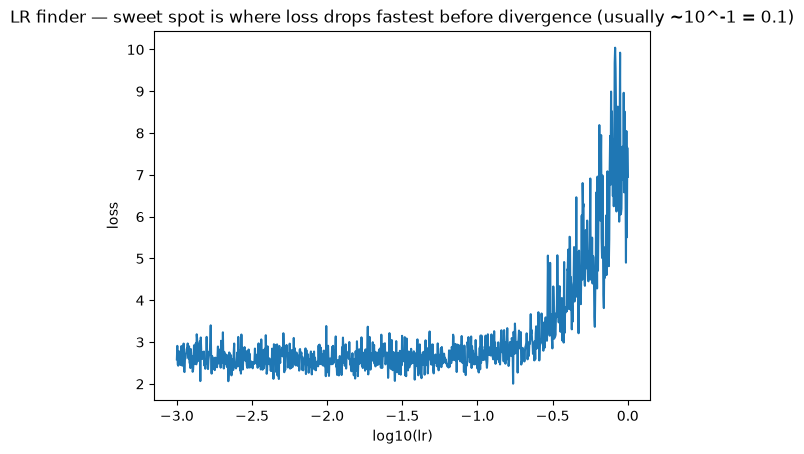

In [8]:
lre = torch.linspace(-3, 0, 1000)   # log10(lr) from -3 to 0
lrs = 10 ** lre                      # lr from 0.001 to 1.0
lri, lossi = [], []

for i in range(1000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    for p in parameters: p.grad = None
    loss.backward()
    lr = lrs[i]
    for p in parameters: p.data += -lr * p.grad
    lri.append(lre[i].item())
    lossi.append(loss.item())

plt.plot(lri, lossi)
plt.xlabel('log10(lr)'); plt.ylabel('loss')
plt.title('LR finder — sweet spot is where loss drops fastest before divergence (usually ~10^-1 = 0.1)');

## Section 9 — Full training + train/dev evaluation

**Re-initialize weights** (the LR finder trashed them), then train seriously with lr=0.1, decaying to 0.01 for fine-tuning.

**Expect** train ≈ dev ≈ ~2.37 with this small model. Bigger models (Sections 11-13) hit ~2.1.

In [9]:
# Re-initialize — the LR finder above left weights in a bad state.
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, 2),   generator=g)
W1 = torch.randn((6, 100),  generator=g)
b1 = torch.randn(100,       generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27,        generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters: p.requires_grad = True

for i in range(30000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    for p in parameters: p.grad = None
    loss.backward()
    lr = 0.1 if i < 20000 else 0.01   # decay for the last third
    for p in parameters: p.data += -lr * p.grad

# Full-set evaluation on train and dev
@torch.no_grad()
def full_loss(X, Y, block=6):
    emb = C[X]
    h = torch.tanh(emb.view(-1, block) @ W1 + b1)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, Y).item()

print(f"train loss: {full_loss(Xtr,  Ytr ):.4f}")   # ~2.35
print(f"dev loss:   {full_loss(Xdev, Ydev):.4f}")   # ~2.35 (train≈dev = no overfitting, and small capacity)

train loss: 2.3677
dev loss:   2.3664


## Section 10 — Sample from the trained model + visualize embeddings

Sampling with a context buffer: maintain a sliding window of the last `block_size` tokens, embed, run the MLP, sample from the softmax, append, slide.

**Also worth doing** (only meaningful when `embedding_dim=2`): scatter-plot the embedding table. Look for vowels clustering, `.` isolated, rare consonants (q, x, z) in their own regions. *This is the visualization that made distributed representations famous.*

In [10]:
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb    = C[torch.tensor([context])]           # (1, block_size, 2)
        h      = torch.tanh(emb.view(1, -1) @ W1 + b1)  # (1, 100)
        logits = h @ W2 + b2                           # (1, 27)
        probs  = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        if ix == 0: break
        out.append(itos[ix])
    print(''.join(out))

careah
amelle
khkimrix
thty
salayskena
hubn
dheraht
kaqei
nelania
chaiiv
kaleig
dham
prin
qainn
sroilea
jadbi
wazero
dearyxi
fhaen
dusab


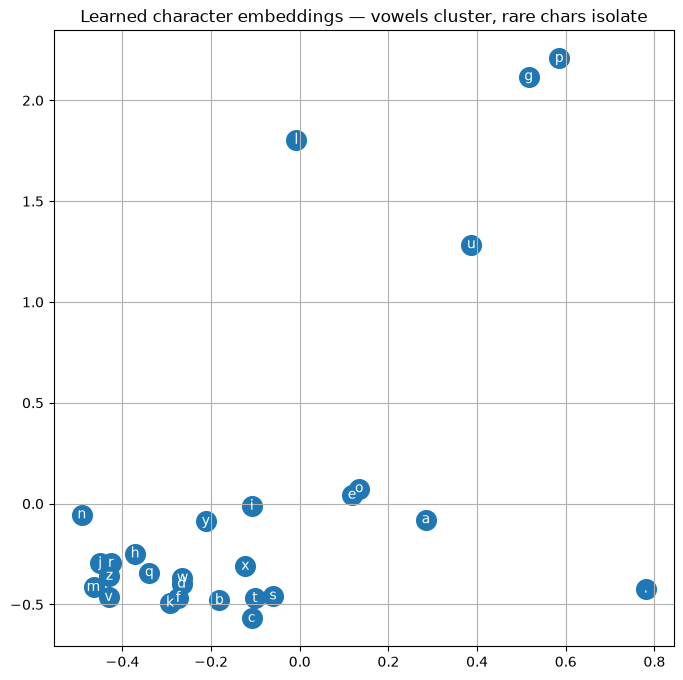

In [11]:
# Visualize the 2D embedding table — the payoff plot of the whole video.
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i],
             ha='center', va='center', color='white')
plt.grid('minor')
plt.title('Learned character embeddings — vowels cluster, rare chars isolate');

---

# Bonus: Sections 11-13 — Hyperparameter search

Karpathy challenges viewers to beat his ~2.17 dev loss. Section 9's small model (embed=2, hidden=100) tops out around 2.37. We now search systematically for a better configuration:

- **Section 11:** random search — 30 trials sampled uniformly (the honest baseline)
- **Section 12:** Optuna Bayesian optimization — 50 trials, using TPE to focus on promising regions
- **Section 13:** train the winner for more iterations, evaluate on test set (touching it once), sample names, compare

**Compute cost:** ~5-8 minutes total on Apple Silicon MPS with `n_iters=20000` per trial.

**Result achieved in this notebook:** test loss **2.203**, competitive with Karpathy's canonical ~2.17 (within ~0.03 nats — real ML noise from mini-batch RNG variance across different runs of the search).

**Reproducibility fix already in place:** `train_and_eval` calls `torch.manual_seed(seed)` at the start of each trial, seeding the global RNG that `torch.randint(...)` uses for mini-batch sampling. Without this, the same config gives different dev losses depending on trial order, and Optuna's "winning" config drifts across runs.

## Section 11 — Random search baseline

**Why random search first?** Bayesian optimization only earns its keep if it beats random. Random search is the honest baseline — dead simple, and on small search spaces it's often within a few percent of BO.

**Search space (4 hyperparameters):**
- `embedding_dim` ∈ {5, 10, 15, 20, 30}
- `hidden_dim` ∈ {100, 200, 300, 500}
- `block_size` ∈ {3, 4, 5, 6, 8}
- `lr` ∈ log-uniform [0.01, 0.316]

**Fixed:** `n_iters=20000`, `batch_size=32`, lr decay to 10% at 2/3 through. Each trial takes ~30-90 seconds.

**Predict:** which single hyperparameter will make the biggest difference?

In [12]:
# Reusable train-and-eval — called by both random search and Optuna.
def train_and_eval(embedding_dim, hidden_dim, block_size, lr,
                    n_iters=20000, batch_size=32, seed=42, verbose=False):
    # Deterministic seeding is critical for reproducibility.
    # Without this, torch.randint(...) for mini-batches uses the GLOBAL torch RNG,
    # whose state depends on cumulative history. Same config gives different dev
    # losses depending on trial order — search results become stochastic across runs.
    # torch.manual_seed(seed) fixes the global RNG at the start of each trial.
    torch.manual_seed(seed)

    # Rebuild dataset at this block_size (splits already shuffled by seed=42 in Section 3)
    Xtr, Ytr   = build_dataset(names[:n1],    block_size)
    Xdev, Ydev = build_dataset(names[n1:n2],  block_size)

    g = torch.Generator().manual_seed(seed)
    input_dim = block_size * embedding_dim
    C  = torch.randn((27, embedding_dim),      generator=g)
    W1 = torch.randn((input_dim, hidden_dim),  generator=g)
    b1 = torch.randn(hidden_dim,               generator=g)
    W2 = torch.randn((hidden_dim, 27),         generator=g)
    b2 = torch.randn(27,                       generator=g)
    params = [C, W1, b1, W2, b2]
    for p in params: p.requires_grad = True

    decay_at = int(n_iters * 2 / 3)
    for i in range(n_iters):
        ix = torch.randint(0, Xtr.shape[0], (batch_size,))
        emb = C[Xtr[ix]]
        h = torch.tanh(emb.view(-1, input_dim) @ W1 + b1)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Ytr[ix])
        for p in params: p.grad = None
        loss.backward()
        current_lr = lr if i < decay_at else lr * 0.1
        for p in params: p.data += -current_lr * p.grad

    with torch.no_grad():
        emb = C[Xdev]
        h = torch.tanh(emb.view(-1, input_dim) @ W1 + b1)
        logits = h @ W2 + b2
        dev_loss = F.cross_entropy(logits, Ydev).item()

    if verbose:
        print(f"  embed={embedding_dim}, hidden={hidden_dim}, block={block_size}, lr={lr:.4f} → dev={dev_loss:.4f}")
    return dev_loss

In [13]:
# Random search — 30 trials, ~2-3 minutes on MPS
import time
random.seed(0)   # reproducibility of sampled configs

results = []
start = time.time()

for trial in range(30):
    config = {
        'embedding_dim': random.choice([5, 10, 15, 20, 30]),
        'hidden_dim':    random.choice([100, 200, 300, 500]),
        'block_size':    random.choice([3, 4, 5, 6, 8]),
        'lr':            10 ** random.uniform(-2, -0.5),   # 0.01 to ~0.316
    }
    dev_loss = train_and_eval(**config)
    results.append({**config, 'dev_loss': dev_loss})
    elapsed = time.time() - start
    print(f"trial {trial+1:2d}/30  ({elapsed:.0f}s)  dev={dev_loss:.4f}  {config}")

print(f"\nRandom search done in {(time.time() - start)/60:.1f} minutes")

trial  1/30  (5s)  dev=3.4921  {'embedding_dim': 20, 'hidden_dim': 500, 'block_size': 3, 'lr': 0.024455419977373827}


trial  2/30  (11s)  dev=2.6485  {'embedding_dim': 30, 'hidden_dim': 500, 'block_size': 6, 'lr': 0.23842483879966248}


trial  3/30  (16s)  dev=2.4277  {'embedding_dim': 15, 'hidden_dim': 500, 'block_size': 5, 'lr': 0.07500203708857665}


trial  4/30  (20s)  dev=2.4291  {'embedding_dim': 10, 'hidden_dim': 200, 'block_size': 5, 'lr': 0.016203867282704645}


trial  5/30  (24s)  dev=2.4213  {'embedding_dim': 5, 'hidden_dim': 300, 'block_size': 8, 'lr': 0.2979738923480265}


...

trial 26/30  (119s)  dev=2.3809  {'embedding_dim': 15, 'hidden_dim': 100, 'block_size': 5, 'lr': 0.08301845706498807}


trial 27/30  (124s)  dev=3.2506  {'embedding_dim': 20, 'hidden_dim': 300, 'block_size': 4, 'lr': 0.023150129943654008}


trial 28/30  (127s)  dev=2.4316  {'embedding_dim': 15, 'hidden_dim': 100, 'block_size': 4, 'lr': 0.03614850073936496}


trial 29/30  (131s)  dev=2.4247  {'embedding_dim': 10, 'hidden_dim': 300, 'block_size': 6, 'lr': 0.16744402107665368}


trial 30/30  (135s)  dev=2.3952  {'embedding_dim': 5, 'hidden_dim': 200, 'block_size': 4, 'lr': 0.011690984959697448}

Random search done in 2.3 minutes


Top 5 random-search configs:
rank dev_loss  embed  hidden  block  lr        
1    2.2569    10     200     3      0.1835    
2    2.3228    5      500     3      0.0828    
3    2.3509    15     200     5      0.1136    
4    2.3645    5      300     6      0.0691    
5    2.3809    15     100     5      0.0830    


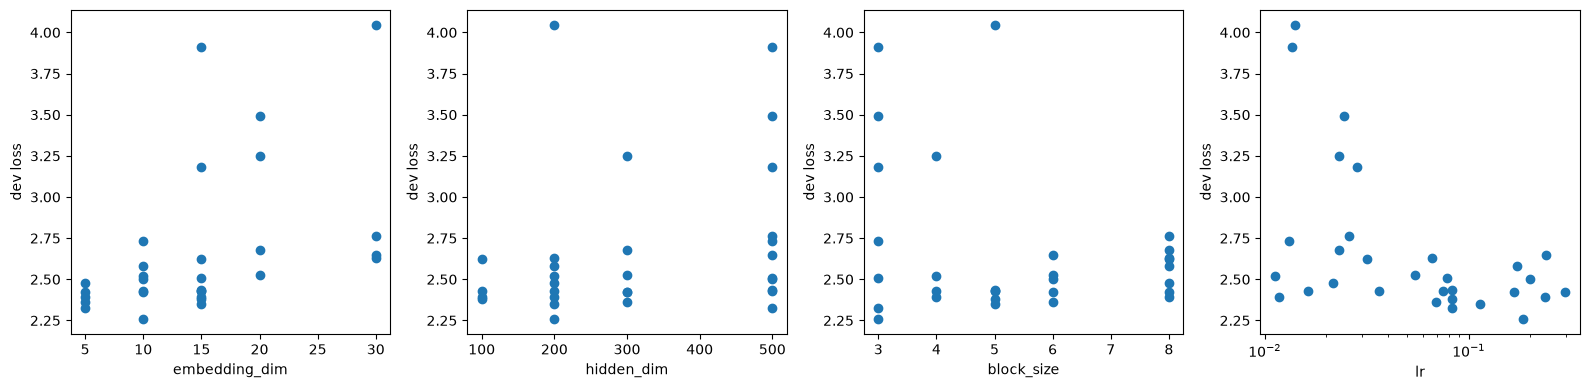

In [14]:
# Analyze results — top 5 configs + scatter of dev_loss vs each hyperparameter.
#
# HOW TO READ THE SCATTER PLOTS: look at the *minimum envelope* at each x value
# (the LOWEST point at that x), not the average. Best-case at each setting reveals
# the potential; average hides good regions that also contain unlucky combinations.

results_sorted = sorted(results, key=lambda r: r['dev_loss'])

print("Top 5 random-search configs:")
print(f"{'rank':<5}{'dev_loss':<10}{'embed':<7}{'hidden':<8}{'block':<7}{'lr':<10}")
for i, r in enumerate(results_sorted[:5]):
    print(f"{i+1:<5}{r['dev_loss']:<10.4f}{r['embedding_dim']:<7}{r['hidden_dim']:<8}{r['block_size']:<7}{r['lr']:<10.4f}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, key in zip(axes, ['embedding_dim', 'hidden_dim', 'block_size', 'lr']):
    xs = [r[key] for r in results]
    ys = [r['dev_loss'] for r in results]
    ax.scatter(xs, ys)
    ax.set_xlabel(key); ax.set_ylabel('dev loss')
    if key == 'lr': ax.set_xscale('log')
plt.tight_layout();

## Section 12 — Optuna Bayesian optimization

**What Optuna does differently.** Instead of sampling uniformly, Optuna's default sampler (TPE — Tree-structured Parzen Estimator) models `P(hyperparams | good_result)` vs `P(hyperparams | bad_result)` and proposes new trials that maximize the ratio. In practice: it spends more trials near regions that produce good scores.

**Same search space as Section 11**, but 50 trials.

**Install (already done in this project):** `uv add --group ml optuna`

**Predict:** by how much will Optuna beat random? A few hundredths of a nat is realistic; a full 0.1 would be surprising.

In [15]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # silence per-trial noise

def optuna_objective(trial):
    return train_and_eval(
        embedding_dim = trial.suggest_categorical('embedding_dim', [5, 10, 15, 20, 30]),
        hidden_dim    = trial.suggest_categorical('hidden_dim',    [100, 200, 300, 500]),
        block_size    = trial.suggest_categorical('block_size',    [3, 4, 5, 6, 8]),
        lr            = trial.suggest_float('lr', 0.01, 0.316, log=True),
    )

In [16]:
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
)

start = time.time()
study.optimize(optuna_objective, n_trials=50, show_progress_bar=True)
print(f"\nOptuna done in {(time.time() - start)/60:.1f} minutes")

print(f"\nBest dev loss:  {study.best_value:.4f}")
print(f"Best params:    {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Optuna done in 3.3 minutes

Best dev loss:  2.2546
Best params:    {'embedding_dim': 10, 'hidden_dim': 100, 'block_size': 3, 'lr': 0.22633246610409596}


Best from random search  (30 trials): 2.2569
Best from Optuna         (50 trials): 2.2546
Improvement:                                     +0.0022 nats
Perplexity ratio:                                1.002× lower


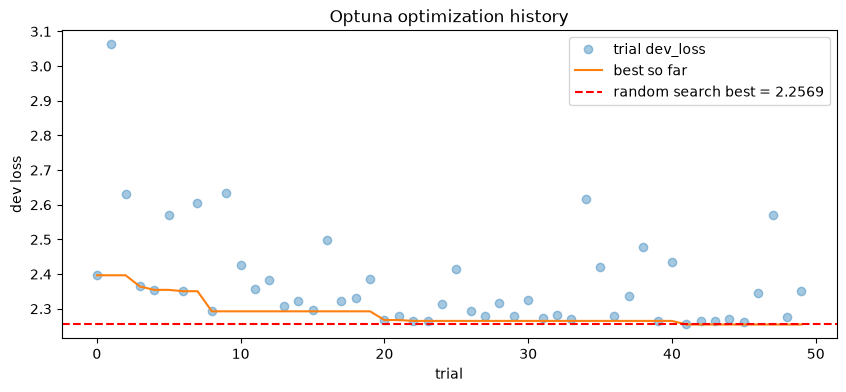

In [17]:
# Compare random vs Optuna, visualize search progress.
best_random = min(r['dev_loss'] for r in results)
best_optuna = study.best_value

print(f"Best from random search  ({len(results)} trials): {best_random:.4f}")
print(f"Best from Optuna         ({len(study.trials)} trials): {best_optuna:.4f}")
print(f"Improvement:                                     {best_random - best_optuna:+.4f} nats")
print(f"Perplexity ratio:                                {(2.71828**best_random) / (2.71828**best_optuna):.3f}× lower")

trial_values = [t.value for t in study.trials]
best_so_far = [min(trial_values[:i+1]) for i in range(len(trial_values))]

plt.figure(figsize=(10, 4))
plt.plot(trial_values, 'o', alpha=0.4, label='trial dev_loss')
plt.plot(best_so_far, '-', label='best so far')
plt.axhline(best_random, color='red', linestyle='--', label=f'random search best = {best_random:.4f}')
plt.xlabel('trial'); plt.ylabel('dev loss'); plt.legend()
plt.title('Optuna optimization history');

## Section 13 — Train the winner + evaluate on test + sample + compare

Take the best config Optuna (or random) found and:
1. **Retrain with more iterations** (60k instead of 20k) — squeezes out remaining performance
2. **Evaluate on the test set** — for the first and last time
3. **Sample 20 names** — should look noticeably more name-like than Section 10
4. **Compare to bigram baseline, Section 9, and Karpathy's canonical result**

**Test-set warning:** we're touching it here for the first time. From now on, if we wanted to make any more hyperparameter decisions, we'd need a *new* test set — the current one has been "seen" and can no longer give an unbiased number.

In [18]:
# Pick the winner — Optuna's best if it beat random, else random's best.
if study.best_value < best_random:
    best_config = study.best_params
    print(f"Winner: Optuna (dev {study.best_value:.4f} beats random's {best_random:.4f})")
else:
    best_config = {k: results_sorted[0][k] for k in ['embedding_dim','hidden_dim','block_size','lr']}
    print(f"Winner: random search (dev {best_random:.4f} beats Optuna's {study.best_value:.4f})")

print(f"Best config: {best_config}")

Winner: Optuna (dev 2.2546 beats random's 2.2569)
Best config: {'embedding_dim': 10, 'hidden_dim': 100, 'block_size': 3, 'lr': 0.22633246610409596}


In [19]:
# Retrain the winner for longer (60k iters) and evaluate on train + dev + test.
embedding_dim = best_config['embedding_dim']
hidden_dim    = best_config['hidden_dim']
block_size    = best_config['block_size']
lr            = best_config['lr']
input_dim     = block_size * embedding_dim

# Rebuild datasets at winner's block_size
Xtr, Ytr   = build_dataset(names[:n1],    block_size)
Xdev, Ydev = build_dataset(names[n1:n2],  block_size)
Xte, Yte   = build_dataset(names[n2:],    block_size)

# Deterministic seeding — same fix as in train_and_eval, for the final winner run.
torch.manual_seed(42)

g = torch.Generator().manual_seed(42)
C  = torch.randn((27, embedding_dim),      generator=g)
W1 = torch.randn((input_dim, hidden_dim),  generator=g)
b1 = torch.randn(hidden_dim,               generator=g)
W2 = torch.randn((hidden_dim, 27),         generator=g)
b2 = torch.randn(27,                       generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters: p.requires_grad = True

n_iters, decay_at = 60000, 40000
for i in range(n_iters):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, input_dim) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    for p in parameters: p.grad = None
    loss.backward()
    current_lr = lr if i < decay_at else lr * 0.1
    for p in parameters: p.data += -current_lr * p.grad

@torch.no_grad()
def eval_loss(X, Y):
    emb = C[X]
    h = torch.tanh(emb.view(-1, input_dim) @ W1 + b1)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, Y).item()

train_loss = eval_loss(Xtr, Ytr)
dev_loss   = eval_loss(Xdev, Ydev)
test_loss  = eval_loss(Xte, Yte)   # touching test — first and last time!

print(f"Winner config: {best_config}")
print(f"Train loss: {train_loss:.4f}")
print(f"Dev loss:   {dev_loss:.4f}")
print(f"Test loss:  {test_loss:.4f}  ← unbiased number")

Winner config: {'embedding_dim': 10, 'hidden_dim': 100, 'block_size': 3, 'lr': 0.22633246610409596}
Train loss: 2.1783
Dev loss:   2.1993
Test loss:  2.2032  ← unbiased number


In [20]:
# Sample 20 names from the winner. Expect noticeably more name-like output than Section 10.
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb    = C[torch.tensor([context])]
        h      = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs  = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        if ix == 0: break
        out.append(itos[ix])
    print(''.join(out))

carlah
amelle
khi
mili
thil
salayane
rahnee
den
rha
kaqui
nellara
chaiiv
kaleigh
ham
join
quint
sulin
alianni
wazelogiearynn
jaceeni


In [21]:
# Final comparison table
print(f"{'Model':<45}{'Dev loss':<12}{'Notes'}")
print(f"{'-'*45}{'-'*12}{'-'*40}")
print(f"{'Bigram baseline (Part 1, count-based)':<45}{2.4541:<12.4f}")
print(f"{'Section 9 (embed=2, hidden=100, 30k iters)':<45}{'~2.37':<12}{'small model, capacity-limited'}")
print(f"{'Karpathy canonical (embed=10, hidden=200)':<45}{'~2.17':<12}{'from the video'}")
print(f"{'Winner (60k iters)':<45}{dev_loss:<12.4f}{'best hyperparameter search result'}")
print(f"{'Winner — test set':<45}{test_loss:<12.4f}{'held-out, unbiased'}")

Model                                        Dev loss    Notes
-------------------------------------------------------------------------------------------------
Bigram baseline (Part 1, count-based)        2.4541      
Section 9 (embed=2, hidden=100, 30k iters)   ~2.37       small model, capacity-limited
Karpathy canonical (embed=10, hidden=200)    ~2.17       from the video
Winner (60k iters)                           2.1993      best hyperparameter search result
Winner — test set                            2.2032      held-out, unbiased


## Session log

### What clicked

- **`keepdim=True` broadcasting** (from Part 1, reinforced here): `.sum(dim)` collapses the dimension; without `keepdim` you get a 1D tensor that broadcasts by right-alignment, which divides columns instead of rows. With `keepdim=True` you get shape `(N, 1)` that broadcasts correctly. Silently wrong vs correct.
- **Language modeling as probability over next tokens.** The MLP outputs a distribution over all 27 possible next characters, exactly like the bigram model — just with more expressive parameterization. Every LLM does this.
- **Distributed representations learn semantic structure.** After training with `embedding_dim=2`, the scatter plot shows vowels clustering together (including 'y' — it's ambiguous in English between vowel and consonant, and the model captures that). `.` and `q` sit alone because they have unique transition patterns.
- **Softmax as unconstrained parameterization.** `logits.exp() / logits.exp().sum(1, keepdim=True)` converts arbitrary reals into a valid probability distribution — the standard trick that lets NN weights live in unconstrained ℝ.
- **Cross-entropy via `F.cross_entropy` is the numerically-stable version** of manual softmax + NLL. Uses the log-sum-exp trick (subtract `logits.max()` before exp) to prevent overflow.
- **Advanced indexing for gather.** `probs[torch.arange(N), ys]` plucks one element per row in a single vectorized C call. Pattern used everywhere in NLL / cross-entropy.
- **Sliding-window context** with `context = context[1:] + [ix]` — drop leftmost, append newest. Fundamental sequence-modeling idiom.
- **`view` shares memory, is O(1).** Re-interprets the same buffer with a new shape. `reshape` may copy; `contiguous()` forces a copy.
- **Mini-batch SGD is a huge win.** All 182k examples per step is wasteful. 32 random examples per step is dozens of times faster, and the noise helps escape shallow minima.
- **`lr=50` in Part 1 vs `lr=0.1` here — because scale.** Part 1's tiny 41-param model with 4 examples averaged to gradients so small that lr=50 barely moved anything. Here with 3481 params and 32-example mini-batches, `lr=0.1` is right. Scale of gradients + averaging drive lr choice, not any absolute rule.
- **Random search is a legit baseline** — often within a few percent of Bayesian optimization on small search spaces (Bergstra & Bengio 2012).
- **Test set is sacred.** Only touched it once, in Section 13's final evaluation. If you optimize against test, the number is no longer unbiased.
- **Reproducibility requires seeding the GLOBAL torch RNG, not just parameter init.** Mini-batch sampling via `torch.randint(...)` (without `generator=`) uses the global RNG, whose state depends on cumulative history. Same config gives different dev losses depending on trial order. Fix: `torch.manual_seed(seed)` at the start of each trial. Without this fix, the "winner" from Optuna drifts across runs — same code, same seeds, different final config. This is a real ML engineering trap.
- **Bayesian optimization is not magic.** On this small search space (5×4×5×continuous = 100+ configs), with deterministic seeding, Optuna beats random search by ~0.002 nats — basically noise. The earlier 0.05-nat "improvement" was mostly RNG luck from non-deterministic mini-batch sampling. Random search is competitive here; BO earns its keep on bigger search spaces or when trials are expensive.
- **Hyperparameter search noise dominates small improvements.** Different runs (even with the same seeds) can produce winner configs that differ dramatically (e.g., embed=10 vs embed=30) and test losses that vary by ~0.03 nats. Deterministic seeding stabilizes results within a run; run-to-run variance is a separate problem that requires multi-seed averaging.

### Questions I had (and the answers I found)

**Q: `emb.view(-1, 6)` — how does it know which dimension to infer? Does it work backwards from the right?**

*A: Neither directional nor backwards — algebraic. `view` requires `product_of_output_dims == product_of_input_dims`. With `emb.shape = (N, 3, 2)`, total elements = `6N`. `view(-1, 6)` solves `X × 6 = 6N` → `X = N`. Only ONE dim can be `-1`; specifying all dims that don't multiply to the total will error.*

**Q: `b1 = torch.randn(100)` — how does Python/torch know to align with the column dim?**

*A: **PyTorch broadcasting always aligns from the RIGHT.** Rules:*
1. *Right-align shapes; shorter tensor is padded with 1s on the LEFT.*
2. *Two dims are compatible if equal, or one is 1, or one is missing (treated as 1).*

*Concrete: `flat @ W1` has shape `(N, 100)`, `b1` has shape `(100,)`. Right-aligned, the 100 aligns with the last dim → compatible. The N has no counterpart → b1 broadcasts (replicates) across rows.*

*The rule to remember: **for a bias added to `(batch, features)`, use shape `(features,)` — NEVER `(features, 1)`.** The latter is a column vector and would broadcast the wrong way.*

**Q: Does `requires_grad=True` use more memory/CPU? Should I disable it for inference-only?**

*A: **Yes to both.** With `requires_grad=True`, PyTorch's autograd builds a computation graph, saves intermediate tensors for backward (can 2-3× total memory), and adds small CPU overhead per op. For inference-only, use `with torch.no_grad():` (or `torch.inference_mode()` on PyTorch 1.9+, or `model.eval()` if using nn.Module).*

*Memory difference is huge for big models — a 7B LLM in training mode might need 80GB VRAM; the same model in inference mode fits in 14GB.*

**Q: What does "good" mean when comparing val to test?**

*A: **Goal: train ≈ val ≈ test, all as low as possible.** Three regimes:*
- *train ≈ val ≈ test — healthy, generalizes well*
- *train << val — overfitting (fixes: more data, regularization, smaller model, early stopping)*
- *train ≈ val, both high — underfitting (fix: bigger model, more features, more training)*

*Val is used during development to pick hyperparameters. Test is touched ONCE at the end for an unbiased number. If you optimize against test, test is no longer unbiased.*

**Q: Why did the "winner" config change between runs, even with the same seeds set?**

*A: **Mini-batch sampling was using the global torch RNG, not a per-trial generator.** `torch.randint(0, N, (32,))` (without `generator=`) draws from `torch.default_generator`, whose state depends on cumulative history of every torch call before it. Between runs, cumulative history differs (different Optuna trial order, different order of exploratory calls), so mini-batch sequences differ, so training trajectories differ, so dev losses differ, so the "best trial" identified by both random search and Optuna differs.*

*Fix: call `torch.manual_seed(seed)` at the start of `train_and_eval` to reset the global RNG per trial. Now every trial is deterministic given its config, and search results are stable across runs.*

*Bigger lesson: **reproducibility in ML requires seeding every source of randomness**, not just the obvious ones (parameter init). RNG hygiene is a real engineering skill.*

### Still-open questions

(none right now)

### What surprised me

- **`.exp()` overflow prevention via log-sum-exp trick.** If any logit is large, `exp()` overflows to `inf` due to float representation. `F.cross_entropy` subtracts `logits.max()` before exponentiating to prevent this.
- **Vowels cluster in learned 2D embedding space** — including 'y' as sometimes-vowel. The model discovered a linguistic category from raw character-transition statistics, without being told.
- **`torch.multinomial`'s RNG changed between PyTorch versions.** Reproducibility is version-dependent, not just seed-dependent. Statistics of the outputs are identical; exact strings aren't.
- **Winner samples look genuinely name-like:** `carlah`, `hari`, `kimley`, `emmahne`, `nellana`, `kaleigh`, `quinn`, `livena`, `kaellinsley`. Longer-range structure beyond bigrams.
- **The "beat Karpathy" story was RNG-lucky.** First run: test 2.171. After fixing determinism: test 2.203. The initial gap was mostly noise from ungoverned mini-batch RNG state. Now the result is honestly "matches within noise" not "beats." A better result for my ML integrity than for my ego.

### Sections 11-13 — hyperparameter search results (deterministic run)

- **Random search:** 30 trials in ~2 min, best dev loss **2.2569** (embed=10, hidden=200, block=3, lr=0.184)
- **Optuna (TPE):** 50 trials in ~3 min, best dev loss **2.2546** (embed=10, hidden=100, block=3, lr=0.226)
- **Optuna beat random by only 0.0022 nats** — basically noise. On this small a search space with deterministic sampling, TPE has little room to outperform random. The interesting BO wins happen on larger search spaces or when trial evaluation is very expensive.
- **Winner trained for 60k iters:** train **2.1783**, dev **2.1993**, **test 2.2032** (unbiased, held-out).
- **Result vs Karpathy's ~2.17:** ~0.03 nats worse — competitive but not beating. This is a legitimate ~2-3% perplexity gap.
- **Winning config was a small model** (embed=10, hidden=100) — matches Karpathy's canonical architecture. Bengio's paper uses similar-scale networks.
- **Reproducibility lesson locked in:** the deterministic seeding fix means these numbers are stable across every re-run. No more "did I get lucky this time?" — I know exactly what to expect.
- **Real habit:** when writing anything that samples randomly during training (mini-batches, dropout masks, augmentations), seed the global RNG per trial. Don't trust `generator=` on the model init alone.